# Radial Density
Radial density defined as $\rho(r) = \langle \Psi(r')| \delta(r - r') | \Psi(r')\rangle$. Let $\hat{\rho}(r) = \delta(r-r')$.
## Complex Scaling
$\hat{\rho}_\theta(r) = \delta(r - r'e^{i\theta}) = e^{-i\theta}\delta(re^{-i\theta} - r')$. Thus,
$$
\rho_\theta(r) = \Gamma e^{-i\theta} u_\theta^2(re^{-i\theta}),
$$
where $\Gamma = \int d\Omega\; (Y_0^0(\Omega))^2$.
## Backrotated Density
Back-rotate resonance wavefunction: $\Psi_{\theta,BR}(r) = \frac{u_\theta(e^{-i\theta}r)}{e^{-i\theta}r}$ to recover Gamow state, then compute density with un-rotated density operator. Thus,
$$
\rho_{\theta, BR}(r) = \Gamma e^{2i\theta} u_\theta^2(e^{-i\theta}r)
$$

In [1]:
from dvr import *

In [2]:
# define system parameters
n = 256                      # number of DVR grid points
phi = pi / 24                # rotation angle
real_res = 1.606 - 1j*0.047  # expected value of resonance
L = 50.0                     # system size

save_plots = True           # save plots or not

gauss_s = lambda r: 2.0 * exp(-((r-3.0)/1.5)**2) # potentialTikhonov

In [3]:
x_plot = np.linspace(0.0, L, 500)

In [4]:
# resonance wavefunction at phi=pi/24
test_system = DVR(n, L, rotation_angle=phi, potential=gauss_s)
_, eigstate = test_system.closest_to_resonance(real_res)
eigstate = eigstate[:, 0] / sqrt(np.sum(eigstate[:, 0]**2)) # c-normalizing just in case

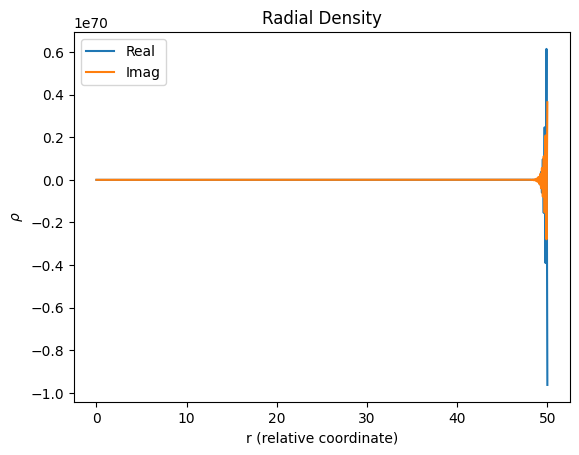

Even CS'd radial density depends on back-rotated resonance which blows up for large r.


In [5]:
# compute density
radial_density = exp(-1j*phi) * test_system.construct_wavefunc(eigstate, x_plot*exp(-1j*phi))**2

fig, ax = plt.subplots()
ax.plot(x_plot, np.real(radial_density), label='Real')
ax.plot(x_plot, np.imag(radial_density), label='Imag')
ax.set_xlabel("r (relative coordinate)")
ax.set_ylabel(r"$\rho$")
ax.set_title(r"Radial Density")
ax.legend()
if save_plots:
    plt.savefig(f"./plots/CS_radial_density.png")
plt.show()

# Density is tougher than r^2 because even the CS density relies on the back-rotated resonance, which blows up.
# The e^-i\theta term should exactly kill the divergence, but errors propagate.
# That's why this operator is so much harder than r^2. We can't rotate the radius operator independently, but we can for r^2.
print("Even CS'd radial density depends on back-rotated resonance which blows up for large r.")

## EC back-rotation

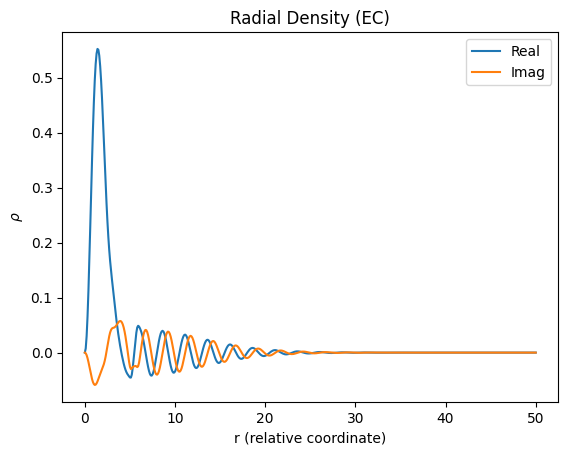

In [6]:
# EC back-rotation
phi_train = np.linspace(pi/24, pi/6, 50)

test_EC = ECSystem(n, L, real_res, potential=gauss_s)
test_EC.train(phi_train)
test_EC.construct_basis()

ec_density = test_EC.grab_wavefunc_from_prediction(0.0, x_plot)**2

fig, ax = plt.subplots()
ax.plot(x_plot, np.real(ec_density), label='Real')
ax.plot(x_plot, np.imag(ec_density), label='Imag')
ax.set_xlabel("r (relative coordinate)")
ax.set_ylabel(r"$\rho$")
ax.set_title(r"Radial Density (EC)")
ax.legend()
if save_plots:
    plt.savefig(f"./plots/ec_radial_density.png")
plt.show()

## Tikhonov Regularization
For details, see `tikhonov_regtest.ipynb`. $\rho_{\theta,BR}(r) = \Gamma e^{2i\theta} \tilde{f}_\theta(x+i\theta)$, where $\tilde{f}_\theta(x) = u^2_\theta(r_0 e^{-x})$ where $x=-\log(r/r_0)$, $r0=1.0$.

In [7]:
# compute numerical FFT

# compute log mesh
r0 = 1.0 # reference scale
xmin = -np.log(L / r0)
xmax = 8
N = 512
x = np.linspace(xmin, xmax, N)
r_log = r0 * exp(-x)

# compute wavefunction evaluated on log mesh
u_on_logmesh = test_system.construct_wavefunc(eigstate, r_log)
f = (u_on_logmesh)**2

# compute FFT
# np.fft gives discrete FFT. Need Delta x / sqrt(2pi)
# to approx integral
f_hat = np.fft.fft(f) * (x[1] - x[0]) / sqrt(2*pi)
xi = np.fft.fftfreq(N, d=(x[1]-x[0])) * 2*pi

# apply tikhonov filter 
kappa = 4e-4
tikhonov = 1.0 / (1.0 + kappa * exp(-2*phi*xi))
# multiply by N because numpy ifft has 1/N factor that numpy fft doesn't 
f_reg = np.fft.ifft(f_hat * tikhonov * exp(-phi*xi)) * N * (xi[1] - xi[0]) / sqrt(2*pi)

# compute density
tikhonov_density = exp(2j*phi) * f_reg

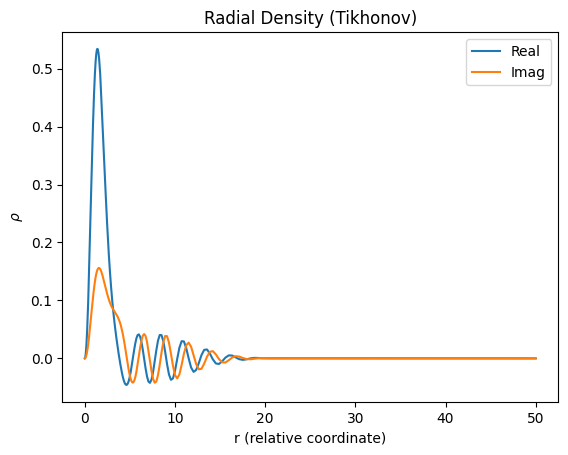

In [8]:
fig, ax = plt.subplots()
ax.plot(r_log, np.real(tikhonov_density), label='Real')
ax.plot(r_log, np.imag(tikhonov_density), label='Imag')
ax.set_xlabel("r (relative coordinate)")
ax.set_ylabel(r"$\rho$")
ax.set_title(r"Radial Density (Tikhonov)")
ax.legend()
if save_plots:
    plt.savefig(f"./plots/tikhonov_radial_density.png")
plt.show()

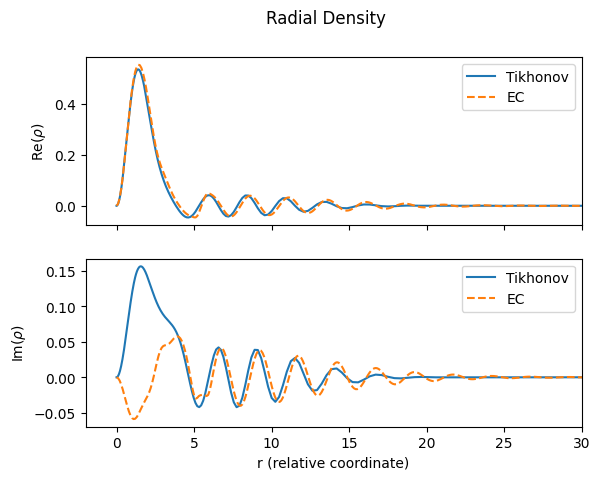

In [9]:
fig, (ax, ax1) = plt.subplots(2, 1, sharex=True)
ax.plot(r_log, np.real(tikhonov_density), label='Tikhonov')
ax.plot(x_plot, np.real(ec_density), '--', label='EC')
ax.set_ylabel(r"Re($\rho$)")

ax1.plot(r_log, np.imag(tikhonov_density), label='Tikhonov')
ax1.plot(x_plot, np.imag(ec_density), '--', label='EC')
ax1.set_ylabel(r"Im($\rho$)")
ax1.set_xlabel("r (relative coordinate)")
ax.legend()  

ax1.legend()
ax.set_xlim([-2, 30])
fig.suptitle(r"Radial Density")
if save_plots:
    plt.savefig(f"./plots/tikhonov_ec_density_comparison.png")
plt.show()

## Tikhonov Regularization to find $\rho_\theta(r)$ at multiple non-zero $\phi$
Using Tikhonov regularization to find the rotated density $\rho_\theta$ in a range of $\phi$. This is not the back-rotated density.

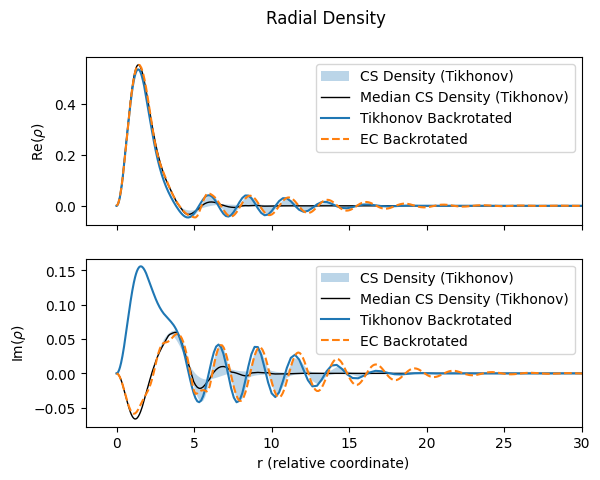

In [10]:
tikhonov_system = Tikhonov(n, L, resonance_energy=real_res, potential=gauss_s)

phis = np.linspace(pi/23, pi/7, 10)

fig, (ax, ax1) = plt.subplots(2, 1, sharex=True)

# plot envelope of curves for many phi
real_us, imag_us = [], []
for phi in phis:
    rs, us = tikhonov_system.compute_density(phi, backrotate=False)
    real_us.append(np.real(us))
    imag_us.append(np.imag(us))

real_us = np.stack(real_us, axis=0)
imag_us = np.stack(imag_us, axis=0)

ax.fill_between(rs, real_us.min(axis=0), real_us.max(axis=0), alpha=0.3, label="CS Density (Tikhonov)")
ax1.fill_between(rs, imag_us.min(axis=0), imag_us.max(axis=0), alpha=0.3, label="CS Density (Tikhonov)")

# plot median curve
ax.plot(rs, np.median(real_us, axis=0), lw=1, alpha=1.0, color='black', label='Median CS Density (Tikhonov)')
ax1.plot(rs, np.median(imag_us, axis=0), lw=1, alpha=1.0, color='black', label='Median CS Density (Tikhonov)')

ax.plot(r_log, np.real(tikhonov_density), label='Tikhonov Backrotated')
ax.plot(x_plot, np.real(ec_density), '--', label='EC Backrotated')
ax1.plot(r_log, np.imag(tikhonov_density), label='Tikhonov Backrotated')
ax1.plot(x_plot, np.imag(ec_density), '--', label='EC Backrotated')

ax.set_ylabel(r"Re($\rho$)")
ax1.set_ylabel(r"Im($\rho$)")
ax1.set_xlabel("r (relative coordinate)")
ax.legend() 
ax1.legend()
ax.set_xlim([-2, 30])
fig.suptitle(r"Radial Density")
if save_plots:
    plt.savefig(f"./plots/tikhonov_ec_density_comparison_wTikhonovCSband.png")
plt.show()

## EC to find $\rho_\theta(r)$ at multiple non-zero $\phi$
Using EC to find the rotated density $\rho_\theta$ in a range of non-zero $\phi$. This is not the back-rotated density.

This also fails for the same reason that Tikhonov was introduced. EC gives us the complex-scaled resonance at $\phi$. The rotated density operator at $\phi$ is still evaluated at $u_\theta(re^{-i\theta})$. So, even though this is analytically fine, small errors will still blow up (we end up having to "reference" the back-rotated wavefunction). Tikhonov only still works because it blindly cuts off all UV modes and thereby also cuts off errors. At $\phi=0$, things are different: EC gives us the back-rotated wavefunction at $\phi=0$, with all of the regulated information already present. So, the density is just evaluated with $\theta=0$: $\rho_{\theta=0,BR} = \Gamma u_{\theta=0}(r)^2$.

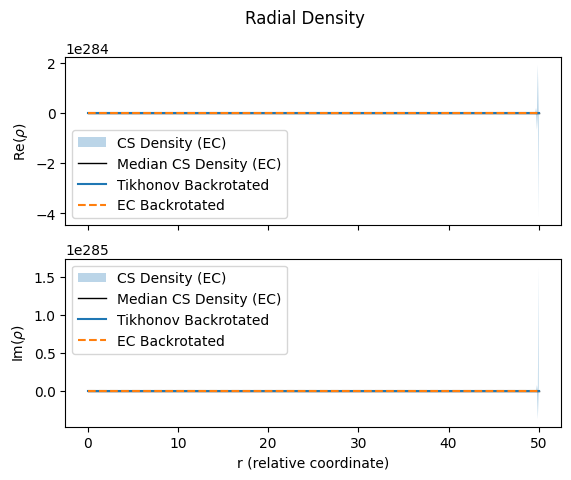

In [11]:
phis = np.linspace(pi/23, pi/7, 10)
fig, (ax, ax1) = plt.subplots(2, 1, sharex=True)
# plot envelope of curves for many phi
real_us, imag_us = [], []
for phi in phis:
    rhos = test_EC.grab_density_from_prediction(phi, x_plot, rotate_rr=True)
    real_us.append(np.real(rhos))
    imag_us.append(np.imag(rhos))

real_us = np.stack(real_us, axis=0)
imag_us = np.stack(imag_us, axis=0)

ax.fill_between(x_plot, np.min(real_us, axis=0), np.max(real_us, axis=0), alpha=0.3, label="CS Density (EC)")
ax1.fill_between(x_plot, np.min(imag_us, axis=0), np.max(imag_us, axis=0), alpha=0.3, label="CS Density (EC)")

# plot median curve|
ax.plot(x_plot, np.median(real_us, axis=0), lw=1, alpha=1.0, color='black', label='Median CS Density (EC)')
ax1.plot(x_plot, np.median(imag_us, axis=0), lw=1, alpha=1.0, color='black', label='Median CS Density (EC)')

ax.plot(r_log, np.real(tikhonov_density), label='Tikhonov Backrotated')
ax.plot(x_plot, np.real(ec_density), '--', label='EC Backrotated')
ax1.plot(r_log, np.imag(tikhonov_density), label='Tikhonov Backrotated')
ax1.plot(x_plot, np.imag(ec_density), '--', label='EC Backrotated')

ax.set_ylabel(r"Re($\rho$)")
ax1.set_ylabel(r"Im($\rho$)")
ax1.set_xlabel("r (relative coordinate)")
ax.legend() 
ax1.legend()
ax.set_xlim([-2, 30])
fig.suptitle(r"Radial Density")
if save_plots:
    plt.savefig(f"./plots/tikhonov_ec_density_comparison_wECCSband.png")
plt.show()

## EC Backrotation w/ Stats
Using multiple EC systems to compute the back-rotated density and computing stats for where the range will likely fall.

In [12]:
import random

seed = 1
random.seed(seed)
np.random.seed(seed)

In [13]:
# number of EC systems
n_ecsystems = 128

# training region
phi_training_range, num_phi_points = [pi/24, pi/6], 20

# construct EC ensemble and train all ECs
EC_ensemble = ECEnsemble(n_ecsystems, n, L, real_res, potential=gauss_s)
EC_ensemble.train(phi_training_range, num_phi_points)
EC_ensemble.construct_bases()

predict_density, predict_density_err95, predict_density_err68 = EC_ensemble.extrapolate_density([0.0], x_plot, rotate_rr=False)

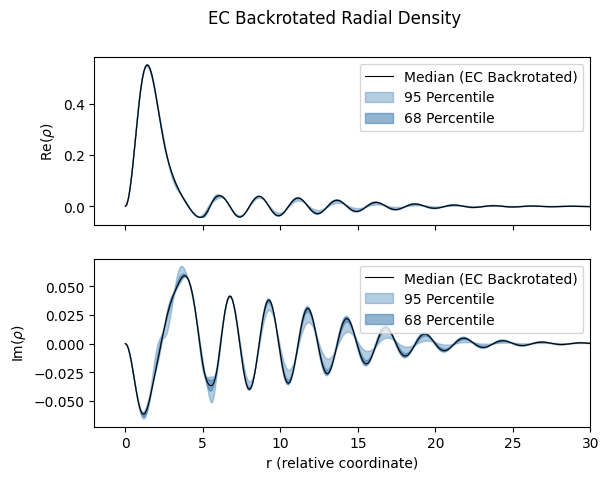

In [21]:
fig, (ax, ax1) = plt.subplots(2, 1, sharex=True)
ax.plot(x_plot, np.real(predict_density[0]), label='Median (EC Backrotated)', linewidth=0.8, alpha=1.0, color='black')
ax.fill_between(x_plot, np.real(predict_density[0]) - np.real(predict_density_err95[0, 0, :]),
                np.real(predict_density_err95[1, 0, :]) + np.real(predict_density[0]), alpha=0.4, color='steelblue', label="95 Percentile")
ax.fill_between(x_plot, np.real(predict_density[0]) - np.real(predict_density_err68[0, 0, :]),
                np.real(predict_density_err68[1, 0, :]) + np.real(predict_density[0]), alpha=0.6, color='steelblue', label="68 Percentile")

ax1.plot(x_plot, np.imag(predict_density[0]), label='Median (EC Backrotated)', linewidth=0.8, alpha=1.0, color='black')
ax1.fill_between(x_plot, np.imag(predict_density[0]) - np.imag(predict_density_err95[0, 0, :]),
                         np.imag(predict_density[0]) + np.imag(predict_density_err95[1, 0, :]), alpha=0.4, color='steelblue', label="95 Percentile")
ax1.fill_between(x_plot, np.imag(predict_density[0]) - np.imag(predict_density_err68[0, 0, :]), 
                         np.imag(predict_density[0]) + np.imag(predict_density_err68[1, 0, :]), alpha=0.6, color='steelblue', label="68 Percentile")

ax.set_ylabel(r"Re($\rho$)")
ax1.set_ylabel(r"Im($\rho$)")
ax1.set_xlabel("r (relative coordinate)")
ax.legend() 
ax1.legend()
ax.set_xlim([-2, 30])
fig.suptitle(r"EC Backrotated Radial Density")
if save_plots:
    plt.savefig(f"./plots/ec_backrotate_density_wstats.png")
plt.show()